# Incrementality Analysis with NeuralProphet
Isolate the true impact of ASO/UA events using time-series forecasting.

**Method:** Train on pre-event data → forecast baseline → compare to actuals → measure incremental lift

---

## 1. Install dependencies

In [2]:
import sys
!{sys.executable} -m pip install neuralprophet pandas numpy matplotlib scipy --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


## 2. Imports

In [3]:
import sys
import warnings
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
warnings.filterwarnings("ignore")

# ── Monkey-patch: fix NeuralProphet 0.9.0 incompatibility with pandas 2+/3+ ──
# NeuralProphet calls pd.to_datetime(..., utc=True).view(np.int64) which was
# removed in pandas 2.0. We patch get_freq_dist to use .asi8 instead.
import neuralprophet.df_utils as _df_utils

def _patched_get_freq_dist(ds_col):
    converted_ds = pd.to_datetime(ds_col, utc=True)
    int_vals = pd.Series(converted_ds.values.astype(np.int64), index=ds_col.index)
    diff_ds = np.unique(int_vals.diff(), return_counts=True)
    return diff_ds

_df_utils.get_freq_dist = _patched_get_freq_dist

from neuralprophet import NeuralProphet

logging.getLogger("NP").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

np.random.seed(42)
print(f"pandas {pd.__version__} | numpy {np.__version__} | Python {sys.version.split()[0]}")
print("Patch applied. NeuralProphet ready.")


pandas 3.0.2 | numpy 1.26.4 | Python 3.11.15
Patch applied. NeuralProphet ready.


In [4]:
# Verify correct Python environment
import sys
print(sys.executable)


/usr/local/opt/python@3.11/bin/python3.11


## 3. Load your data

NeuralProphet expects a DataFrame with exactly two columns:
- `ds` — date (datetime)
- `y`  — metric (installs, impressions, revenue, etc.)

Replace the synthetic data below with your real data.

In [5]:
# =============================================================================
# OPTION A: Synthetic demo data (delete this block when using real data)
# =============================================================================
def generate_demo_data(event_date="2024-11-05", event_lift=0.8, post_duration=30):
    dates = pd.date_range(start="2022-01-01", end="2025-01-31", freq="D")
    n = len(dates)
    trend  = np.linspace(1000, 1500, n)
    weekly = 150 * np.sin(2 * np.pi * np.arange(n) / 7)
    yearly = 200 * np.sin(2 * np.pi * np.arange(n) / 365)
    noise  = np.random.normal(0, 80, n)
    y = trend + weekly + yearly + noise
    df = pd.DataFrame({"ds": dates, "y": y})
    event = pd.Timestamp(event_date)
    mask = (df["ds"] >= event) & (df["ds"] <= event + pd.Timedelta(days=post_duration))
    df.loc[mask, "y"] *= (1 + event_lift)
    df["y"] = df["y"].clip(lower=0).round()
    return df

df_full = generate_demo_data(event_date="2024-11-05", event_lift=0.79)

# =============================================================================
# OPTION B: App Store Connect
# -----------------------------------------------------------------------------
# 1. App Store Connect -> Analytics -> App Units (або Installs)
# 2. Вибери весь доступний діапазон (до 3 роки) -> Export (.csv)
# 3. Типова структура файлу:
#    Date,App Units
#    2022-01-01,1523
#    2022-01-02,1487
#
# df_full = pd.read_csv("app_store_connect.csv", parse_dates=["Date"])
# df_full = df_full.rename(columns={"Date": "ds", "App Units": "y"})
# df_full["ds"] = pd.to_datetime(df_full["ds"])
# df_full = df_full[["ds", "y"]].dropna().sort_values("ds").reset_index(drop=True)

# =============================================================================
# OPTION C: Google Play Console
# -----------------------------------------------------------------------------
# 1. Play Console -> Statistics -> вибери метрику (Installs / Store Listing Visitors)
# 2. Export -> CSV
# 3. Типова структура файлу:
#    Date,Daily Device Installs
#    2022-01-01,984
#    2022-01-02,1012
#
# df_full = pd.read_csv("play_console.csv", parse_dates=["Date"])
# df_full = df_full.rename(columns={"Date": "ds", "Daily Device Installs": "y"})
# df_full["ds"] = pd.to_datetime(df_full["ds"])
# df_full = df_full[["ds", "y"]].dropna().sort_values("ds").reset_index(drop=True)

# =============================================================================
# OPTION D: AppTweak CSV export
# -----------------------------------------------------------------------------
# 1. AppTweak -> App -> Downloads (або Keyword Impressions) -> Export
# 2. Типова структура:
#    date,downloads
#    2022-01-01,1345
#
# df_full = pd.read_csv("apptweak_export.csv", parse_dates=["date"])
# df_full = df_full.rename(columns={"date": "ds", "downloads": "y"})
# df_full["ds"] = pd.to_datetime(df_full["ds"])
# df_full = df_full[["ds", "y"]].dropna().sort_values("ds").reset_index(drop=True)

# =============================================================================
# Перевірка даних (працює для будь-якого варіанту)
# =============================================================================
date_min = df_full["ds"].min().date()
date_max = df_full["ds"].max().date()
y_min    = df_full["y"].min()
y_max    = df_full["y"].max()
missing  = pd.date_range(df_full["ds"].min(), df_full["ds"].max()).difference(df_full["ds"]).size

print(f"Data shape: {df_full.shape}")
print(f"Date range: {date_min} -> {date_max}")
print(f"Metric range: {y_min:.0f} - {y_max:.0f}")
print(f"Missing dates: {missing}")
df_full.tail()


Data shape: (1127, 2)
Date range: 2022-01-01 -> 2025-01-31
Metric range: 628 - 2755
Missing dates: 0


,ds,y
1122,2025-01-27,1785.0
1123,2025-01-28,1565.0
1124,2025-01-29,1660.0
1125,2025-01-30,1360.0
1126,2025-01-31,1509.0


## 3.5 Holidays & Outliers

Dates listed here are **excluded from model training** to keep the baseline clean.
Country holidays are added to NeuralProphet as learned regressors.

In [6]:
# ── Holidays / Outliers ─────────────────────────────────────────────────────
# Option A: Built-in country holidays (NeuralProphet learns their effect).
# ISO 3166-1 alpha-2 codes. Set [] to disable.
COUNTRY_HOLIDAYS = []   # e.g. ['US', 'UA']

# Option B: Known outlier dates to exclude from training.
# Single day: 'YYYY-MM-DD'   |   Range: ('YYYY-MM-DD', 'YYYY-MM-DD')
OUTLIER_DATES = [
    # 'YYYY-MM-DD',
    # ('YYYY-MM-DD', 'YYYY-MM-DD'),
]


## 4. Define the event

Set the event start date and the analysis window.

In [7]:
# ── Configure your event ───────────────────────────────────────────────────
EVENT_DATE      = '2024-11-05'   # Event start (e.g. metadata update, campaign launch)
EVENT_END       = '2024-11-12'   # Event end (use same as start for single-day events)
POST_EVENT_DAYS = 31             # How many days after the event to measure lingering effect
MODEL           = 'extrapolation'  # 'extrapolation' (long-term) or 'interpolation' (short-term)

event_start  = pd.Timestamp(EVENT_DATE)
event_end    = pd.Timestamp(EVENT_END)
analysis_end = event_end + pd.Timedelta(days=POST_EVENT_DAYS)

# Split: train on pre-event data only (extrapolation)
df_train = df_full[df_full['ds'] < event_start].copy()

# For interpolation: also exclude the event window (train on pre + post)
if MODEL == 'interpolation':
    df_post  = df_full[df_full['ds'] > analysis_end].copy()
    df_train = pd.concat([df_train, df_post]).sort_values('ds')

print(f"Event:      {EVENT_DATE} → {EVENT_END}")
print(f"Post window: {POST_EVENT_DAYS} days until {analysis_end.date()}")
print(f"Training points: {len(df_train)} days")
# ── Exclude outlier dates from training ─────────────────────────────────────
_outlier_set = set()
for _entry in OUTLIER_DATES:
    if isinstance(_entry, tuple):
        _outlier_set.update(pd.date_range(_entry[0], _entry[1]))
    else:
        _outlier_set.add(pd.Timestamp(_entry))

if _outlier_set:
    _before = len(df_train)
    df_train = df_train[~df_train['ds'].isin(_outlier_set)].copy()
    _removed = _before - len(df_train)
    if _removed == 0:
        print('Warning: OUTLIER_DATES specified but no matching rows found in training data')
    else:
        print(f'Outlier dates removed from training: {_removed}')
print(f'Training points after outlier exclusion: {len(df_train)}')


Event:      2024-11-05 → 2024-11-12
Post window: 31 days until 2024-12-13
Training points: 1039 days
Training points after outlier exclusion: 1039


## 5. Train NeuralProphet

AppTweak uses NeuralProphet to capture **trends, weekly & yearly seasonality**, and **holiday effects**.

In [8]:
# Build model
model = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    quantiles=[0.025, 0.975],
    epochs=100,
    batch_size=64,
    learning_rate=0.01,
    trainer_config={"enable_progress_bar": True},
)

# Add country-specific holidays from COUNTRY_HOLIDAYS config
for _country in COUNTRY_HOLIDAYS:
    try:
        model.add_country_holidays(country_name=_country)
        print(f'Added holidays: {_country}')
    except Exception as _e:
        print(f'Warning: could not add holidays for {_country!r}: {_e}')

metrics = model.fit(df_train, freq="D")
print("Model trained successfully")

loss_col = "Loss" if "Loss" in metrics.columns else metrics.columns[1]
print(f"Final train loss: {metrics[loss_col].iloc[-1]:.4f}")


Training: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Model trained successfully
Final train loss: 0.0109


## 6. Generate baseline forecast

In [9]:
# Days to forecast: from end of training data to end of analysis window
n_forecast_days = (analysis_end - df_train["ds"].max()).days + 1

future   = model.make_future_dataframe(df_train, periods=n_forecast_days)
forecast = model.predict(future)

print("Forecast columns:", [c for c in forecast.columns if "yhat" in c])

# NeuralProphet 0.9 with quantiles uses: yhat1, yhat1 2.5%, yhat1 97.5%
# Pick column names defensively
col_hat   = "yhat1"
col_lower = next((c for c in forecast.columns if "2.5" in c), None)
col_upper = next((c for c in forecast.columns if "97.5" in c), None)

if col_lower is None or col_upper is None:
    # Fallback: quantiles not available, use hat only
    print("Warning: quantile columns not found, CI will be empty")
    forecast["ci_lower"] = forecast[col_hat]
    forecast["ci_upper"] = forecast[col_hat]
    col_lower, col_upper = "ci_lower", "ci_upper"

df_actual   = df_full[(df_full["ds"] >= event_start) & (df_full["ds"] <= analysis_end)].copy()
df_forecast = forecast[forecast["ds"] >= event_start].copy()

df_analysis = pd.merge(
    df_actual,
    df_forecast[["ds", col_hat, col_lower, col_upper]],
    on="ds", how="inner"
).rename(columns={
    "y":       "actual",
    col_hat:   "baseline",
    col_lower: "lower_95",
    col_upper: "upper_95",
})

df_analysis["lift_abs"] = df_analysis["actual"] - df_analysis["baseline"]
df_analysis["lift_pct"] = df_analysis["lift_abs"] / df_analysis["baseline"] * 100

print(f"Analysis window: {len(df_analysis)} days ({event_start.date()} -> {analysis_end.date()})")
df_analysis.head()


Predicting: |          | 0/? [00:00<?, ?it/s]

Forecast columns: ['yhat1', 'yhat1 2.5%', 'yhat1 97.5%']
Analysis window: 39 days (2024-11-05 -> 2024-12-13)


,ds,actual,baseline,lower_95,upper_95,lift_abs,lift_pct
0,2024-11-05,2588.0,1373.352783,1275.005615,1373.352783,1214.647217,88.443933
1,2024-11-06,2451.0,1234.710205,1125.965454,1234.710205,1216.289795,98.508119
2,2024-11-07,2003.0,1159.635986,1060.848877,1159.635986,843.364014,72.726616
3,2024-11-08,2280.0,1203.266724,1109.951904,1216.662964,1076.733276,89.484173
4,2024-11-09,2334.0,1319.401611,1230.397949,1319.401611,1014.598389,76.898374


## 7. Statistical significance (p-value)

A p-value < 0.05 means the impact is unlikely due to chance.

In [10]:
def significance_test(residuals):
    """One-sample t-test: are residuals (actual - baseline) significantly different from 0?"""
    t_stat, p_value = stats.ttest_1samp(residuals, popmean=0)
    return t_stat, p_value

# Event window
event_mask = (df_analysis['ds'] >= event_start) & (df_analysis['ds'] <= event_end)
post_mask  = (df_analysis['ds'] > event_end)

event_data = df_analysis[event_mask]
post_data  = df_analysis[post_mask]

t_event, p_event = significance_test(event_data['lift_abs'])
t_post,  p_post  = significance_test(post_data['lift_abs'])

total_lift_abs = df_analysis['lift_abs'].sum()
avg_lift_pct   = df_analysis['lift_pct'].mean()

print("━" * 55)
print(f"  EVENT WINDOW ({EVENT_DATE} → {EVENT_END})")
print(f"  Avg daily lift:  {event_data['lift_abs'].mean():+.0f} installs/day")
print(f"  Avg lift %:      {event_data['lift_pct'].mean():+.1f}%")
print(f"  p-value:         {p_event:.4f}  {'✅ Significant' if p_event < 0.05 else '❌ Not significant'}")
print("━" * 55)
print(f"  POST-EVENT ({(event_end + pd.Timedelta(days=1)).date()} → {analysis_end.date()})")
print(f"  Avg daily lift:  {post_data['lift_abs'].mean():+.0f} installs/day")
print(f"  Avg lift %:      {post_data['lift_pct'].mean():+.1f}%")
print(f"  p-value:         {p_post:.4f}  {'✅ Significant' if p_post < 0.05 else '❌ Not significant'}")
print("━" * 55)
print(f"  TOTAL incremental installs: {total_lift_abs:+,.0f}")
print(f"  Overall avg lift: {avg_lift_pct:+.1f}%")
print("━" * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EVENT WINDOW (2024-11-05 → 2024-11-12)
  Avg daily lift:  +1116 installs/day
  Avg lift %:      +84.5%
  p-value:         0.0000  ✅ Significant
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  POST-EVENT (2024-11-13 → 2024-12-13)
  Avg daily lift:  +769 installs/day
  Avg lift %:      +57.3%
  p-value:         0.0000  ✅ Significant
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TOTAL incremental installs: +32,771
  Overall avg lift: +62.9%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## 8. Visualization

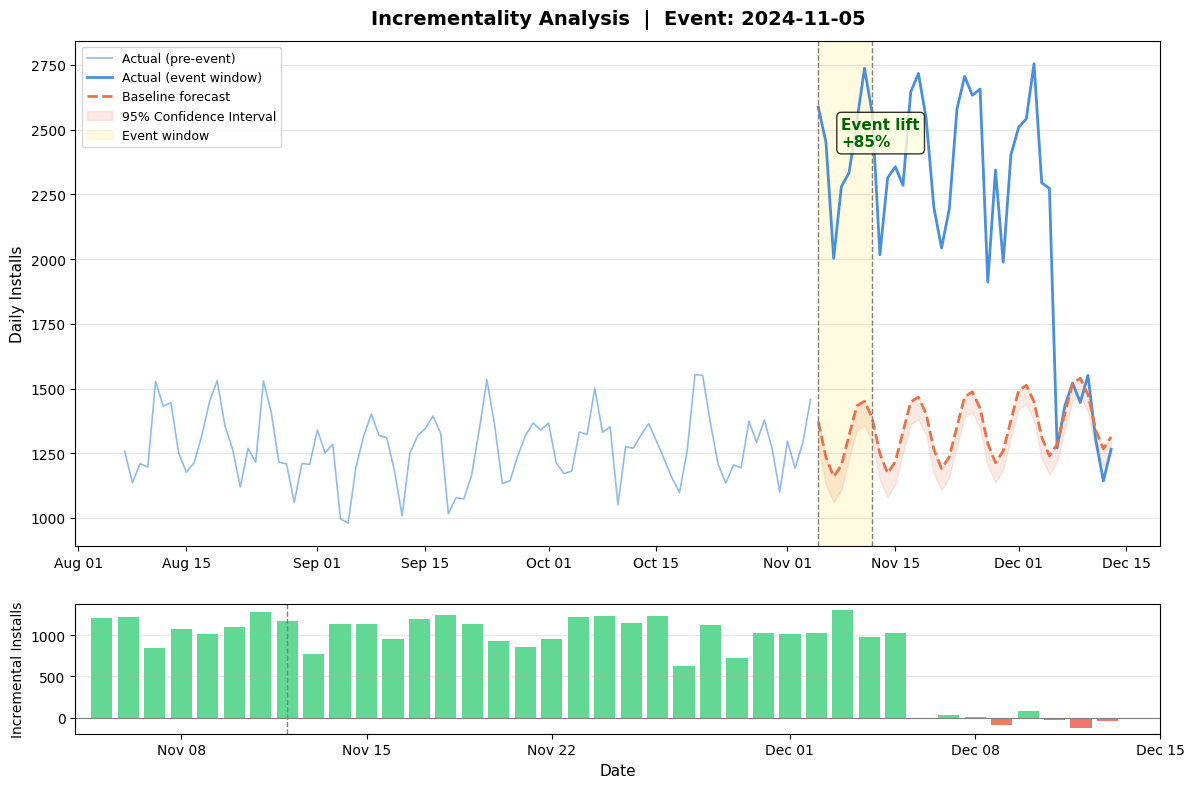

Plot saved -> incrementality_result.png


In [11]:
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

# Два незалежних subplots через GridSpec
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.45)
ax1 = fig.add_subplot(gs[0:3, 0])  # верхня панель: 3/4 висоти
ax2 = fig.add_subplot(gs[3, 0])    # нижня панель: 1/4 висоти, НЕЗАЛЕЖНА вісь X

# ── Top panel ─────────────────────────────────────────────────────────────
lookback_start = event_start - pd.Timedelta(days=90)
df_pre = df_full[(df_full["ds"] >= lookback_start) & (df_full["ds"] < event_start)]

ax1.plot(df_pre["ds"], df_pre["y"],
         color="#4a90d9", alpha=0.6, linewidth=1.2, label="Actual (pre-event)")
ax1.plot(df_analysis["ds"], df_analysis["actual"],
         color="#4a90d9", linewidth=2, label="Actual (event window)")
ax1.plot(df_analysis["ds"], df_analysis["baseline"],
         color="#e8734a", linewidth=2, linestyle="--", label="Baseline forecast")
ax1.fill_between(
    df_analysis["ds"],
    df_analysis["lower_95"],
    df_analysis["upper_95"],
    alpha=0.15, color="#e8734a", label="95% Confidence Interval"
)
ax1.axvspan(event_start, event_end, alpha=0.12, color="gold", label="Event window")
ax1.axvline(event_start, color="gray", linewidth=1, linestyle="--")
ax1.axvline(event_end,   color="gray", linewidth=1, linestyle="--")

# Mark outlier dates on the top panel
for _entry in OUTLIER_DATES:
    _s = pd.Timestamp(_entry[0] if isinstance(_entry, tuple) else _entry)
    _e = pd.Timestamp(_entry[1] if isinstance(_entry, tuple) else _entry)
    if _e >= lookback_start and _s <= analysis_end:
        if _s == _e:
            ax1.axvline(_s, color='red', linewidth=0.8, linestyle=':', alpha=0.5)
        else:
            ax1.axvspan(_s, _e, alpha=0.08, color='red')

avg_lift   = event_data["lift_pct"].mean()
lift_label = "Event lift\n" + f"{avg_lift:+.0f}%"
ax1.annotate(
    lift_label,
    xy=(event_start + pd.Timedelta(days=3), df_analysis[event_mask]["actual"].mean()),
    fontsize=11, fontweight="bold",
    color="darkgreen" if avg_lift > 0 else "darkred",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8)
)
ax1.set_title(f"Incrementality Analysis  |  Event: {EVENT_DATE}",
              fontsize=14, fontweight="bold", pad=12)
ax1.set_ylabel("Daily Installs", fontsize=11)
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Bottom panel: тільки event + post-event ────────────────────────────────
# Повністю незалежна вісь X — не пов'язана з ax1
df_bars = df_analysis[df_analysis["ds"] >= event_start].copy()

bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_bars["lift_abs"]]
ax2.bar(df_bars["ds"], df_bars["lift_abs"], color=bar_colors, alpha=0.75, width=0.8)
ax2.axhline(0, color="gray", linewidth=0.8)

# set_xlim ДО axvspan
x_min = mdates.date2num(event_start.to_pydatetime()) - 1
x_max = mdates.date2num(analysis_end.to_pydatetime()) + 2
ax2.set_xlim(x_min, x_max)

ax2.axvline(event_end, color="gray", linewidth=1, linestyle="--")

ax2.set_ylabel("Incremental Installs", fontsize=10)
ax2.set_xlabel("Date", fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.grid(axis="y", alpha=0.3)

plt.savefig("incrementality_result.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved -> incrementality_result.png")


## 9. Export results

In [12]:
df_export = df_analysis.copy()
df_export['period'] = np.where(
    (df_export['ds'] >= event_start) & (df_export['ds'] <= event_end), 'event',
    np.where(df_export['ds'] > event_end, 'post-event', 'pre-event')
)

df_export = df_export.round(2)
df_export.to_csv('incrementality_results.csv', index=False)
print("Results saved → incrementality_results.csv")
df_export.head(15)

Results saved → incrementality_results.csv


,ds,actual,baseline,lower_95,upper_95,lift_abs,lift_pct,period
0,2024-11-05,2588.0,1373.349976,1275.010010,1373.349976,1214.65,88.44,event
1,2024-11-06,2451.0,1234.709961,1125.969971,1234.709961,1216.29,98.51,event
2,2024-11-07,2003.0,1159.640015,1060.849976,1159.640015,843.36,72.73,event
3,2024-11-08,2280.0,1203.270020,1109.949951,1216.660034,1076.73,89.48,event
4,2024-11-09,2334.0,1319.400024,1230.400024,1319.400024,1014.60,76.90,event
5,2024-11-10,2530.0,1433.050049,1338.859985,1433.050049,1096.95,76.55,event
6,2024-11-11,2737.0,1451.359985,1357.310059,1451.359985,1285.64,88.58,event
7,2024-11-12,2564.0,1385.920044,1294.540039,1385.920044,1178.08,85.00,event
8,2024-11-13,2017.0,1247.750000,1146.180054,1247.750000,769.25,61.65,post-event
9,2024-11-14,2314.0,1173.160034,1081.729980,1173.160034,1140.84,97.24,post-event


---
## Usage notes

| Parameter | What to change |
|---|---|
| `EVENT_DATE` / `EVENT_END` | Your ASO/UA event dates |
| `POST_EVENT_DAYS` | How long to measure post-event |
| `MODEL` | `extrapolation` for long-term, `interpolation` for short-term on/off tests |
| `df_full` (Option B) | Replace with your real CSV from AppTweak / MMP / App Store Connect |
| `add_country_holidays` | Add holidays for your target market |
| `n_changepoints` | Increase for more volatile data, decrease for smoother baseline |

### Data sources for `y` column
- **App Store Connect** → Installs, Impressions, Conversion Rate
- **AppTweak API / Export** → Download estimates, Keyword impressions
- **MMP (Adjust, AppsFlyer)** → Attributed installs, Revenue
- **Google Play Console** → Installs, Ratings count